# 1. Import and Install Dependensies
#### รันทุกครั้ง

In [ ]:
# !pip install tensorflow==2.4.1 tensorflow-gpu==2.4.1 opencv-python mediapipe sklearn matplotlib # From the tutorial, too old.
# Run this in the terminal instead : 
# uv venv --python 3.10
# .venv\Scripts\activate
# (Copy both lines together but don't forget to remove the "#")
# Then : uv pip install ipykernel "tensorflow==2.12.0" "mediapipe==0.10.5" "protobuf==3.20.3" "numpy<2" opencv-python scikit-learn matplotlib

In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Holistic
#### รัน 4 ตัวแรกทุกครั้ง

In [3]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [4]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # COLOR CONVERSION BGR 2 GRB    The Color Swap: OpenCV naturally reads colors backwards as BGR (Blue-Green-Red). MediaPipe's AI is trained on standard RGB. Your new function translates the colors so the AI can actually "see" the image properly.
    image.flags.writeable = False                   # Image is no longer writeable
    results = model.process(image)                  # Make prediction               This is where the actual machine learning happens! MediaPipe is now actively scanning every single frame of your video to find your face, shoulders, and fingers.
    image.flags.writeable = True                    # Image is now weiteable
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)  # COLOR CONVERSION GRB 2 BGR
    return image, results

In [5]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections (use .FACE_CONNECTIONS for older MediaPipe version)
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connection

In [6]:
def draw_styled_landmarks(image, results):
    # Draw face connections (use .FACE_CONNECTIONS for older MediaPipe version)
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
                              mp_drawing.DrawingSpec(color=(80, 110, 10), thickness=1, circle_radius=1),
                              mp_drawing.DrawingSpec(color=(80, 256, 121), thickness=1, circle_radius=1)
                              )
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(80, 22, 10), thickness=2, circle_radius=4),
                              mp_drawing.DrawingSpec(color=(80, 44, 121), thickness=2, circle_radius=2)
                              )
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(121, 22, 76), thickness=2, circle_radius=4),
                              mp_drawing.DrawingSpec(color=(121, 44, 250), thickness=2, circle_radius=2)
                              )
    # Draw right hand connection
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=4),
                              mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=2)
                              )

In [ ]:
mp_drawing.draw_landmarks??

In [ ]:
cap = cv2.VideoCapture(0)
# Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)

        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
len(results.face_landmarks.landmark)

In [ ]:
results

In [ ]:
draw_landmarks(frame, results)

In [ ]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values
#### ไม่จำเป็นต้องรัน ตรงนี้มีแค่ไว้ทดสอบผลที่ได้จากการเปิดกล้องอันบน
#### รันอัน def extract_keypoints(results): ทุกครั้ง

In [ ]:
len(results.pose_landmarks.landmark)

In [ ]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [ ]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [ ]:
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)

In [7]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(468*3)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(33*4)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [ ]:
result_test = extract_keypoints(results)

In [ ]:
result_test

In [ ]:
np.save('0', result_test)

In [ ]:
np.load('0.npy')

# 4. Setup Folders for Collection
#### ถ้าไม่ได้จะเทรนก็รันแค่ cell แรก

In [8]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data')

# Settings
no_sequence = 100        # Number of videos you want to record
sequence_length = 30      # Frames per video

In [ ]:
# 1. TYPE THE SINGLE WORD YOU WANT TO RECORD

current_action = 'sorry'  # Change this word for you or your friend!

In [ ]:
# 2. CREATE THE FOLDER FOR JUST THIS WORD

action_path = os.path.join(DATA_PATH, current_action)
for sequence in range(no_sequence):
    try: 
        os.makedirs(os.path.join(action_path, str(sequence)))
    except:
        pass

# 5. Collect Keypoint Values for Training and Testing
#### ถ้าไม่ได้จะเทรนก็ข้ามไปเลย

In [ ]:
# 3. RECORD JUST THIS WORD

cap = cv2.VideoCapture(0)
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # Loop through sequences aka videos
    for sequence in range(no_sequence):
        # Loop through video length aka frames
        for frame_num in range(sequence_length):

            # Read feed and make detections
            ret, frame = cap.read()
            image, results = mediapipe_detection(frame, holistic)
            draw_styled_landmarks(image, results)
            
            # Apply wait logic for the single word
            if frame_num == 0: 
                cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                cv2.putText(image, f'Collecting frames for {current_action} Video {sequence}', (15,12), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)
                cv2.waitKey(2000) # 2-second break between videos
            else: 
                cv2.putText(image, f'Collecting frames for {current_action} Video {sequence}', (15,12), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)
            
            # Export keypoints to the folder
            keypoints = extract_keypoints(results)
            npy_path = os.path.join(action_path, str(sequence), str(frame_num))
            np.save(npy_path, keypoints)

            # Break gracefully if you press 'q'
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break
                
cap.release()
cv2.destroyAllWindows()

In [ ]:
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features
#### ถ้าไม่ได้จะเทรนก็ข้าม 2 cell สุดท้าย

In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [10]:
actions = np.array(['hello', 'thanks', 'iloveyou', 'sorry'])

In [11]:
label_map = {label:num for num, label in enumerate(actions)}

In [12]:
label_map

{'hello': 0, 'thanks': 1, 'iloveyou': 2, 'sorry': 3}

In [13]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequence):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [14]:
np.array(sequences).shape

(400, 30, 1662)

In [15]:
np.array(labels).shape

(400,)

In [16]:
X = np.array(sequences)

In [17]:
X.shape

(400, 30, 1662)

In [18]:
y = to_categorical(labels).astype(int)

In [20]:
y

array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       ...,
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       [0, 0, 0, 1]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [ ]:
y_test.shape

# 7. Build and Train LSTM Neural Network
#### ถ้าไม่ได้จะเทรนก็ข้าม cell รองสุดท้าย

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

from tensorflow.keras.callbacks import EarlyStopping

In [22]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [23]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [24]:
res = [.7, 0.2, 0.1]

In [25]:
actions[np.argmax(res)]

'hello'

In [26]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
early_stopping = EarlyStopping(monitor='categorical_accuracy', patience=50, restore_best_weights=True)
model.fit(X_train, y_train, epochs=2000, callbacks=[tb_callback, early_stopping])

In [ ]:
model.summary()

# 8. Make Predictions
#### ถ้าไม่ได้จะเทรนก็ข้ามไปเลย

In [ ]:
res = model.predict(X_test)

In [ ]:
actions[np.argmax(res[4])]

In [ ]:
actions[np.argmax(y_test[4])]

# 9. Save Weights
#### ถ้าไม่ได้จะเทรนก็ข้าม cell แรก

In [ ]:
model.save('action.h5')

In [ ]:
# del model
# ถ้ารันอันนี้มันจะลบ model ถ้าอยากให้กลับมาให้ไปรันในข้อ 7. อันที่มี model = Sequential()

In [27]:
model.load_weights('action.h5')

# 10. Evaluation using Confustion Matrix and Accuracy
#### ถ้าไม่ได้จะเทรนก็ข้ามไปเลย

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [ ]:
yhat = model.predict(X_test)

In [ ]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [ ]:
multilabel_confusion_matrix(ytrue, yhat)

In [ ]:
accuracy_score(ytrue, yhat)

# 11. Test in Real Time

In [30]:
colors = [(245,117,16), (117,245,16), (16,117,245), (117,16,245)]   # สีที่จะเอาไปแสดงแต่ละผลลัพธ์ที่เรามี
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1) # วาดแท่งสี่เหลี่ยมด้วยความยาวและสีที่ต่างกัน
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA) # เอา text ค่า probability ขึ้นมาแสดง
        
    return output_frame

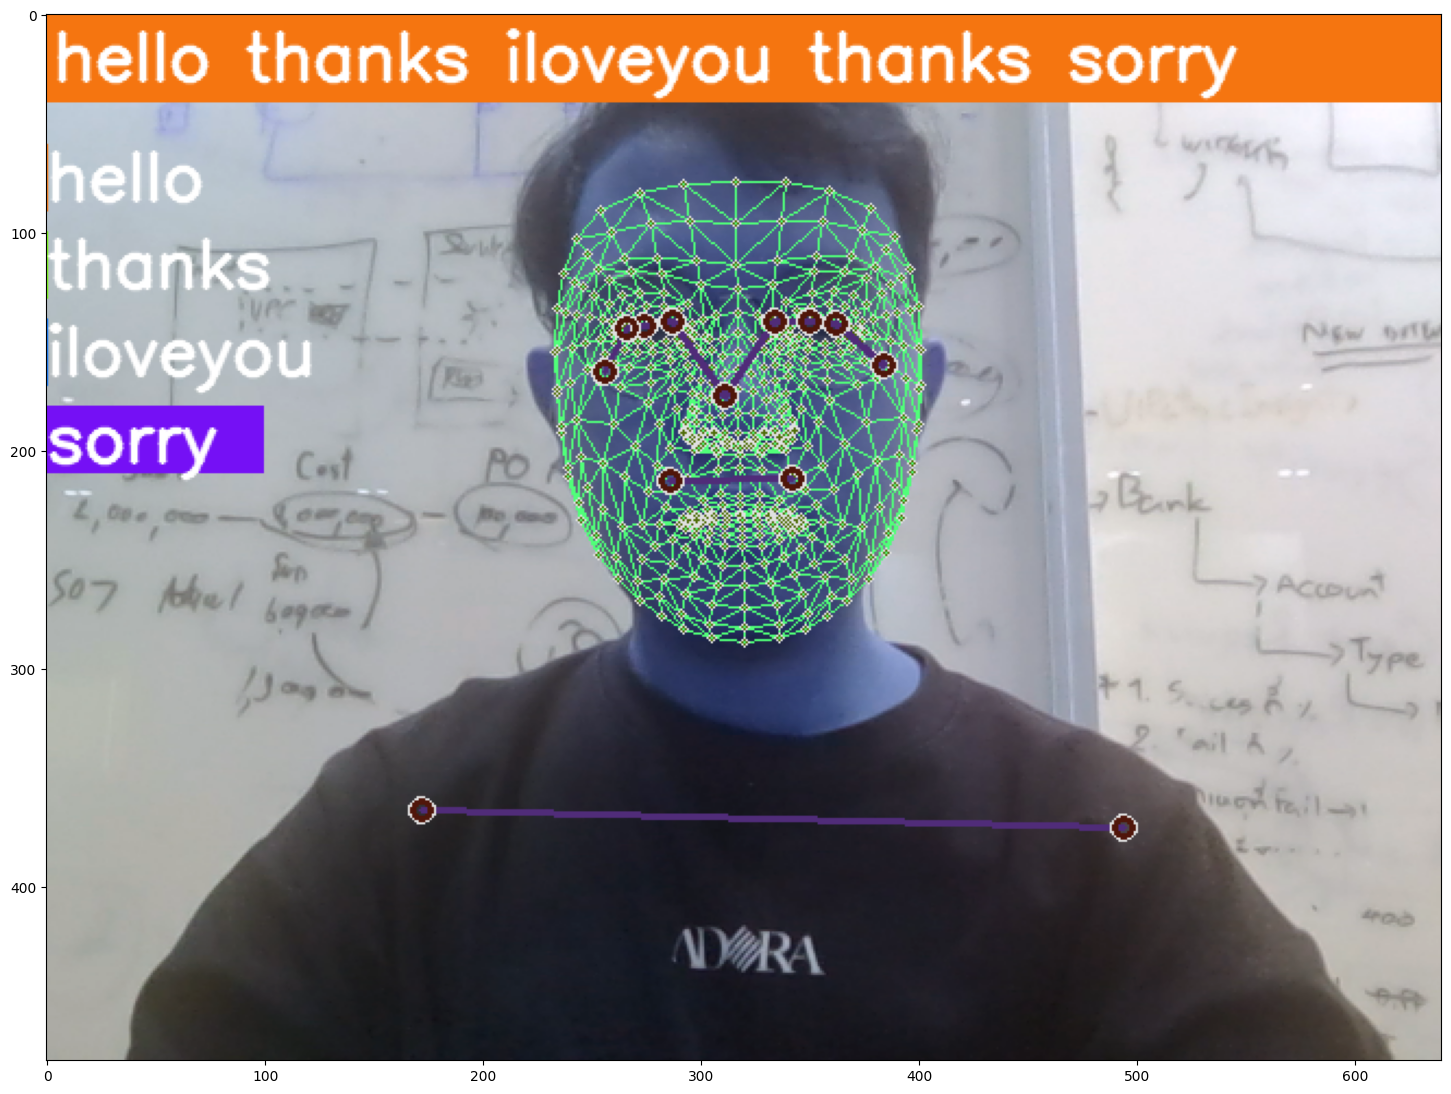

In [31]:
plt.figure(figsize=(18,18))                         # แสดงภาพใหญ่ ๆ
plt.imshow(prob_viz(res, actions, image, colors))   # แสดง probability visualization ของ frame ล่าสุดของเรา

In [ ]:
# 1. New detection variables
sequence = []   # เดี๋ยวจะให้เก็บให้ได้ 30 frames แล้วค่อยทำ prediction
sentence = []   # เก็บประวัติ prediction ที่ได้ทำไป
predictions = []
threshold = 0.7 # ความมั่นใจของ AI ว่าถ้ามั่นใจเกินนี้ก็ทำ prediction ได้เลย

cap = cv2.VideoCapture(0)
# Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)

        # Draw landmarks
        draw_styled_landmarks(image, results)

        # 2. Prediction logic
        keypoints = extract_keypoints(results)  # แกะท่าของ frame นี้
        # sequence.insert(0, keypoints)         # (ซึ่งไม่ควร) แล้วเอาท่าที่แกะมาไปไว้หน้าสุดใน sequence (O(N))
        # sequence = sequence[:30]              # (ซึ่งผิด — แต่ที่ใช้อันนี้ตอนแรกเพราะเราทะลึ่งเอา frame ไปต่อหน้า) เอา 30 frames แรก
        sequence.append(keypoints)              # แล้วเอาท่าที่แกะมาไปต่อท้ายใน sequence (O(1))
        sequence = sequence[-30:]               # แล้วจากนั้น เราจะเอา 30 frames ล่าสุด

        if len(sequence) == 30:                 # แล้วพอครบ 30 frames แล้ว...
            res = model.predict(np.expand_dims(sequence, axis=0))[0]    # รัน prediction
            print(actions[np.argmax(res)])      # print ผลลัพธ์
            predictions.append(np.argmax(res))

            # 3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res):             # 10 frames ล่าสุดต้อง predict เป็นอันเดียวกันก่อน เพื่อป้องกันมันเดาไปเรื่อยแล้วแสดงผลลัพธ์ระหว่างเรากำลังเปลี่ยนท่า (false detection)
                if res[np.argmax(res)] > threshold: # ถ้า AI เรามั่นใจเกินที่ threshold ตั้งไว้ก็...
                    if len(sentence) > 0:           # เช็คว่ามีประวัติบ้างรึยัง
                        if actions[np.argmax(res)] != sentence[-1]:         # ถ้ามีก็เช็คว่าที่ predict ได้มานี่ไม่ใช่คำเดิมไหม ถ้ามันไม่ใช่คำเดิมก็เอาผลลัพธ์ที่ predict มาไปต่อใน sequence ถ้ามันเป็นอันเดิมก็ไม่ต้องทำอะไร
                            sentence.append(actions[np.argmax(res)])

                            # NEW: Wipe the memory to force a cooldown!
                            sequence = []
                    else:                           # ถ้ายังไม่มีประวัติอะไรก็เอาผลลัพธ์ที่ predict มาไปต่อใน sequence เฉย ๆ เลย จะเรียกว่าเป็นตัว initial เลยก็ได้
                        sentence.append(actions[np.argmax(res)])

                        # NEW: Wipe the memory here too!
                        sequence = []

            if len(sentence) > 5:               # ให้ array sentence นี้มีแค่ 5 ผลลัพธ์ของ prediction ล่าสุดพอ
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)   # เอา Probability Visualization ขึ้นมาแสดง

        cv2.rectangle(image, (0, 0), (640, 40), (245, 117, 16), -1)     # สร้างกล่องสีฟ้าด้านบนจากซ้าย
        cv2.putText(image, ' '.join(sentence), (3, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)   # เอา text sequence ที่เรามีไปแสดงด้านบนจากซ้าย

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [ ]:
res[np.argmax(res)] > threshold

In [ ]:
(num_sequences, 30, 1662)

In [ ]:
model.predict(np.expand_dims(X_test[0], axis=0))